# 前置操作

1. 安装环境
conda create -n hla_analysis biopython numpy pandas matplotlib seaborn  tqdm openpyxl pymol scikit-learn -c conda-forge -c schrodinger

2. 从IEDB https://www.iedb.org/database_export_v3.php 下载如下文件

iedb_3d_full.zip

3. 解压后使用mhc_3d_assays.csv中获取想要的HLA型别的含有肽段的PDB ID

4. 使用curl下载到本地(如果有更多就放到一个脚本里面批量下载)

curl -O https://files.rcsb.org/download/1DLH.pdb

5. 使用接下来的代码计算距离


## 关于PDB文件及蛋白结构的相关说明

### 识别 alpha / beta / peptide
从PDB文件中可以找到关于alpha / beta / peptide三者的描述，如下所示：

REMARK 300 MOLECULE 1 : ALPHA CHAIN - RESIDUES  A   3 THROUGH A 182             
REMARK 300            : BETA  CHAIN - RESIDUES  B   3 THROUGH B 190             
REMARK 300            : PEPTIDE     - RESIDUES  C 306 THROUGH C 318             
REMARK 300            : SUGARS      - RESIDUES  A 501, B 511, B 512,            
REMARK 300                                      B 521                           
REMARK 300 MOLECULE 2 : ALPHA CHAIN - RESIDUES  D   3 THROUGH D 182             
REMARK 300            : BETA  CHAIN - RESIDUES  E   3 THROUGH E 190             
REMARK 300            : PEPTIDE     - RESIDUES  F 306 THROUGH F 318             
REMARK 300            : SUGARS      - RESIDUES  D 501, E 511, E 512,            
REMARK 300                                      E 521                           
REMARK 300     WATERS : MOL1 + MOL2 - RESIDUES      1 THROUGH 153              

可以看到 ABC分别是alpha / beta / peptide，同时 DEF是副本，我们在pymol中可以给不同的链标记颜色，如下图所示：

![alt text](image-7.png)

这里 红色，黄色和蓝色分别对应ABC

通常 A/B/C 是第一个生物学复合体的副本（primary biological assembly）
D/E/F 是重复单位（symmetry mate）或对称结构
而文献中提到：processed to contain only a single biological assembly”
这表示文献 刻意只选择一个副本（即 A/B/C）来分析，否则同样的分子分析两遍会造成重复。

### PDB的相关内容

ATOM      1  N   GLU A   3      19.098  63.939   8.356  1.00 65.17           N  

| 字段范围  | 内容示例     | 含义解释                                |
| ----- | -------- | ----------------------------------- |
| 1–6   | `ATOM`   | 标记此行为蛋白质原子记录（与 `HETATM` 相对）         |
| 7–11  | `1`      | 原子序号（atom serial number）            |
| 13–16 | `N`      | 原子名（Atom name，例如 N 表示主链的氮原子）        |
| 17    | 空格       | 保留位，用于区分原子类型（略）                     |
| 18–20 | `GLU`    | 所属氨基酸残基的三字母代码（此处为谷氨酸 Glutamic Acid） |
| 22    | `A`      | 链 ID（chain identifier）              |
| 23–26 | `3`      | 氨基酸残基编号（residue sequence number）    |
| 31–38 | `19.098` | X 坐标（以 Å 为单位）                       |
| 39–46 | `63.939` | Y 坐标                                |
| 47–54 | `8.356`  | Z 坐标                                |
| 55–60 | `1.00`   | 占据率（occupancy，通常为 1.00，表示完全占据）      |
| 61–66 | `65.17`  | B-factor（温度因子，反映原子位置的热运动或不确定性）      |
| 77–78 | `N`      | 元素符号（Element Symbol，这里是氮 N）         |

| 原子名称 | 说明                       |
| ---- | ------------------------ |
| N    | 胺基的氮原子                   |
| CA   | α-碳原子（主链）← 这是你提取坐标时通常使用的 |
| C    | 羧基的碳原子                   |
| O    | 羧基的氧原子                   |
| CB   | β-碳原子（支链）                |
| OG1  | 羟基氧原子（支链）                |
| CG2  | 另一个支链碳原子                 |


In [1]:
from Bio.PDB import PDBParser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def get_ca_coords(structure, chain_id):
    """提取指定链的所有 Cα 坐标"""
    coords = []
    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                for residue in chain:
                    if 'CA' in residue:
                        resid = residue.get_id()[1]  # 残基编号
                        coords.append((resid, residue['CA'].coord))
    return coords

def compute_min_distances(pdb_path, beta_chain='B', peptide_chain='C'):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)
    
    beta_ca = get_ca_coords(structure, beta_chain)
    peptide_ca = get_ca_coords(structure, peptide_chain)

    min_dists = []
    for res_id, beta_coord in beta_ca:
        dists = [np.linalg.norm(beta_coord - pep_coord) for _, pep_coord in peptide_ca]
        min_dist = min(dists)
        min_dists.append((res_id, min_dist))
    
    return pd.DataFrame(min_dists, columns=["Residue_ID", "Min_Distance"])


## 上述计算距离代码的说明如下：
| 行号 | 代码                                            | 解释                                               |
| -- | --------------------------------------------- | ------------------------------------------------ |
| 1  | `def get_ca_coords(structure, chain_id):`     | 定义函数：从结构对象中提取某个链的所有 Cα 原子的编号和三维坐标                |
| 2  | `"""提取指定链的所有 Cα 坐标"""`                        | 文档注释，说明功能                                        |
| 3  | `coords = []`                                 | 初始化一个空列表，用于存放 `(残基编号, 坐标)` 的元组                   |
| 4  | `for model in structure:`                     | 遍历结构中的每个模型（通常只有一个）                               |
| 5  | `for chain in model:`                         | 遍历该模型下的每条链                                       |
| 6  | `if chain.id == chain_id:`                    | 如果当前链名匹配输入参数（如 "A"）                              |
| 7  | `for residue in chain:`                       | 遍历该链的所有残基（氨基酸）                                   |
| 8  | `if 'CA' in residue:`                         | 判断该残基是否包含 Cα 原子（有时会有缺失）                          |
| 9  | `resid = residue.get_id()[1]`                 | 获取残基的序号，例如第 65 号残基（PDB 中的 resi 编号）               |
| 10 | `coords.append((resid, residue['CA'].coord))` | 存储该残基编号与其 Cα 原子的三维坐标                             |
| 11 | `return coords`                               | 返回所有 Cα 坐标列表，形式如：`[(65, array([x, y, z])), ...]` |

| 行号 | 代码                                                                        | 解释                                         |
| -- | ------------------------------------------------------------------------- | ------------------------------------------ |
| 1  | `def compute_min_distances(pdb_path, beta_chain='B', peptide_chain='C'):` | 定义主函数，参数为 PDB 路径 + 链编号（默认 A 是 HLA β，B 是肽段） |
| 2  | `parser = PDBParser(QUIET=True)`                                          | 创建 Biopython 的 PDB 文件解析器（安静模式）             |
| 3  | `structure = parser.get_structure("complex", pdb_path)`                   | 读取结构，返回一个结构对象（包含模型、链、残基等层级）                |

| 行号 | 代码                                                     | 解释                    |
| -- | ------------------------------------------------------ | --------------------- |
| 4  | `beta_ca = get_ca_coords(structure, beta_chain)`       | 调用上面的函数提取 β 链所有 Cα 坐标 |
| 5  | `peptide_ca = get_ca_coords(structure, peptide_chain)` | 同理提取肽段的 Cα 坐标         |

| 行号 | 代码                                                                                | 解释                             |
| -- | --------------------------------------------------------------------------------- | ------------------------------ |
| 6  | `min_dists = []`                                                                  | 初始化保存最小距离的列表                   |
| 7  | `for res_id, beta_coord in beta_ca:`                                              | 遍历每个 β 链的残基                    |
| 8  | `dists = [np.linalg.norm(beta_coord - pep_coord) for _, pep_coord in peptide_ca]` | 计算该 β 残基到所有肽段残基的 Cα 距离（欧几里得距离） |
| 9  | `min_dist = min(dists)`                                                           | 获取最短距离                         |
| 10 | `min_dists.append((res_id, min_dist))`                                            | 存储：`(残基编号, 最小距离)`              |

| 行号 | 代码                                                                       | 解释              |
| -- | ------------------------------------------------------------------------ | --------------- |
| 11 | `return pd.DataFrame(min_dists, columns=["Residue_ID", "Min_Distance"])` | 转为表格格式，方便分析和可视化 |

## 关于距离的单位说明

在 PDB 文件中（包括你通过 `Biopython` 或 `PyMOL` 加载的结构数据），**所有坐标单位均为 Ångström（Å，埃）**。

---

##### ✅ 1 Å 是什么？

* **1 Ångström = 10⁻¹⁰ 米 = 0.1 纳米（nm）**
* 在结构生物学中，**原子与原子之间的典型距离**（例如 Cα 到 Cα）大约在 **1.5–4.0 Å** 范围内。

---

##### ✅ 举个例子：最短距离的解释

你在计算 HLA β 链每个 Cα 与肽段上所有 Cα 的距离时，比如说：

```python
dist = np.linalg.norm(coord1 - coord2)  # 输出为 3.27
```

这个 `3.27` 就代表：

> β链上某个残基的 Cα 原子与肽段上某个残基的 Cα 原子之间的距离为 **3.27 Å（≈ 0.327 纳米）**

---




In [9]:
df_dist = compute_min_distances("./data/PDB/1DLH.pdb")
print(df_dist.shape)
df_dist.head()


(188, 2)


,Residue_ID,Min_Distance
0,3,27.730133
1,4,24.566868
2,5,21.992943
3,6,19.540154
4,7,15.817518


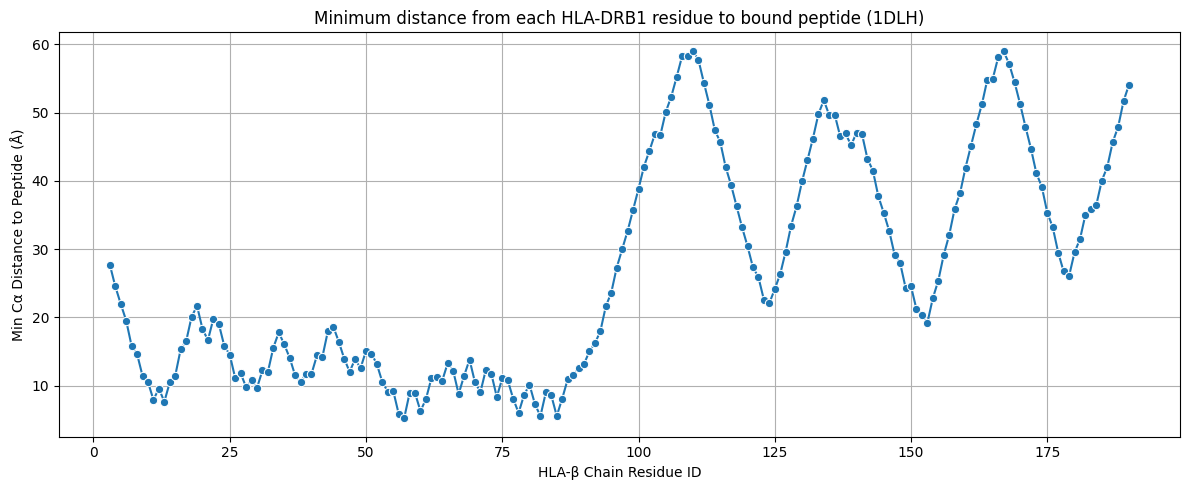

In [8]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_dist, x="Residue_ID", y="Min_Distance", marker='o')
plt.title("Minimum distance from each HLA-DRB1 residue to bound peptide (1DLH)")
plt.xlabel("HLA-β Chain Residue ID")
plt.ylabel("Min Cα Distance to Peptide (Å)")
plt.grid(True)
plt.tight_layout()
plt.show()

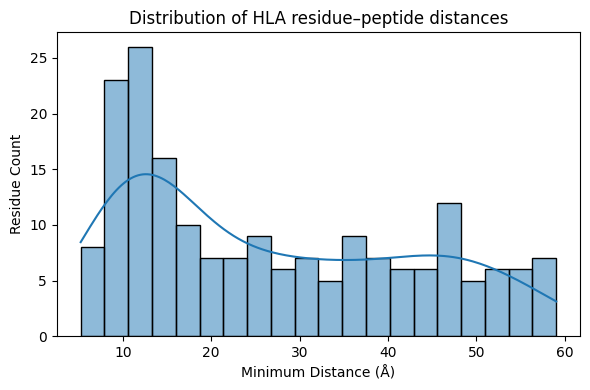

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df_dist["Min_Distance"], bins=20, kde=True)
plt.title("Distribution of HLA residue–peptide distances")
plt.xlabel("Minimum Distance (Å)")
plt.ylabel("Residue Count")
plt.tight_layout()
plt.show()


#  IMGT-to-PDB residue mapping

接下来要做的是PDB中的距离和我们使用IMGT数据库获取的exon2序列翻译的Peptide binding groove 序列的对应(mapping)
文献中使用P+数字来标记氨基酸位置信息，它的详细解释请见：https://hla.alleles.org/pages/wmda/p_groups/
简要说明如下：
- “P70” 指的是 HLA‑DRB1 的第 70 个氨基酸残基（编号基于 exon 2 编码区域）
- 大写 P 表示这是针对共价决定域（exon 2）的标准化编号，不是简单的氨基酸序号

In [ ]:
# 第一步只需要执行如下代码即可完成距离计算和比对过程

from Bio import SeqIO, pairwise2
from Bio.PDB import PDBParser, Polypeptide
from Bio.Data import IUPACData
import numpy as np
import pandas as pd

three_to_one_dict = {k.upper(): v for k, v in IUPACData.protein_letters_3to1.items()}

def load_imgt_sequences(fasta_path):
    imgt_seq_dict = {}
    for record in SeqIO.parse(fasta_path, "fasta"):
        allele = record.id.split()[0]
        imgt_seq_dict[allele] = str(record.seq)
    return imgt_seq_dict


def extract_pdb_sequence_coords(pdb_path, chain_id):
    """提取指定链的氨基酸序列、坐标、残基编号、三字母转一字母"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    sequence = ""
    coords = []
    res_ids = []
    res_aas = []

    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                for residue in chain:
                    if 'CA' in residue:
                        resname = residue.get_resname().upper()
                        aa = three_to_one_dict.get(resname)
                        if not aa:
                            print(f"Unknown amino acid: {resname}, skipping.")
                            continue
                        sequence += aa
                        coords.append(residue['CA'].coord)
                        res_ids.append(residue.get_id()[1])
                        res_aas.append(aa)
    return sequence, coords, res_ids, res_aas


def map_imgt_to_pdb(imgt_seq, pdb_seq, pdb_res_ids, pdb_aas):
    alignment = pairwise2.align.globalms(imgt_seq, pdb_seq, 2, -1, -10, -0.5)[0]
    imgt_aln, pdb_aln = alignment.seqA, alignment.seqB

    imgt_idx, pdb_idx = 0, 0
    mapping = []

    for i in range(len(imgt_aln)):
        if imgt_aln[i] != '-' and pdb_aln[i] != '-':
            mapping.append({
                'IMGT_Pos': imgt_idx + 1,
                'PDB_Residue_ID': pdb_res_ids[pdb_idx],
                'AA': pdb_aas[pdb_idx]
            })
        if imgt_aln[i] != '-':
            imgt_idx += 1
        if pdb_aln[i] != '-':
            pdb_idx += 1
    return pd.DataFrame(mapping)


def compute_min_distances_with_aa(pdb_path, beta_chain='B', peptide_chain='C'):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("complex", pdb_path)

    beta_data = []
    peptide_coords = []

    for model in structure:
        for chain in model:
            if chain.id == beta_chain:
                for residue in chain:
                    if 'CA' in residue:
                        resname = residue.get_resname().upper()
                        aa = three_to_one_dict.get(resname)
                        if not aa:
                            print(f"Unknown amino acid: {resname}, skipping.")
                            continue
                        resid = residue.get_id()[1]
                        coord = residue['CA'].coord
                        beta_data.append((resid, aa, coord))
            elif chain.id == peptide_chain:
                for residue in chain:
                    if 'CA' in residue:
                        peptide_coords.append(residue['CA'].coord)

    results = []
    for resid, aa, coord in beta_data:
        dists = [np.linalg.norm(coord - pep_coord) for pep_coord in peptide_coords]
        min_dist = min(dists)
        results.append((resid, aa, min_dist))

    return pd.DataFrame(results, columns=["PDB_Residue_ID", "AA", "Min_Distance"])


def merge_mapping_and_dist(mapping_df, dist_df):
    return pd.merge(mapping_df, dist_df, on=["PDB_Residue_ID", "AA"], how="left").sort_values("IMGT_Pos")


---

### ✅ 函数结构与解释如下：

```python
def map_imgt_to_pdb(imgt_seq, pdb_seq, pdb_res_ids, pdb_aas):
```

#### 参数：

* `imgt_seq`: 来自 `.fasta` 文件的氨基酸序列字符串（不含gap）。
* `pdb_seq`: 从 PDB 中提取的氨基酸序列字符串（不含gap）。
* `pdb_res_ids`: 与 `pdb_seq` 等长的列表，对应每个氨基酸在 PDB 中的 residue ID（如 1, 2, 3... 或 3, 4, 5...）。
* `pdb_aas`: 与 `pdb_seq` 等长的列表，对应每个氨基酸的单字母缩写（A, R, N, D...）。

---

### 1️⃣ 序列比对（pairwise alignment）

```python
alignment = pairwise2.align.globalms(imgt_seq, pdb_seq, 2, -1, -10, -0.5)[0]
imgt_aln, pdb_aln = alignment.seqA, alignment.seqB
```

* 这使用 **Needleman-Wunsch 全局比对算法** 对 IMGT 序列和 PDB 序列进行比对。

  * `2`: match 得 2 分
  * `-1`: mismatch 扣 1 分
  * `-10`: gap 打开惩罚（gap open penalty）
  * `-0.5`: gap 延伸惩罚（gap extend penalty）
* `alignment.seqA`, `alignment.seqB`：返回比对后的两个序列，可能含有 `-` gap。

---

### 2️⃣ 设置位置索引与映射列表

```python
imgt_idx, pdb_idx = 0, 0
mapping = []
```

* `imgt_idx`: 跟踪 IMGT 序列的位置，从0开始。
* `pdb_idx`: 跟踪 PDB 序列的位置，从0开始。
* `mapping`: 存储每一对比对成功的残基在 IMGT 和 PDB 中的位置信息。

---

### 3️⃣ 遍历比对结果，记录每个对应关系

```python
for i in range(len(imgt_aln)):
    if imgt_aln[i] != '-' and pdb_aln[i] != '-':
        mapping.append({
            'IMGT_Pos': imgt_idx + 1,
            'PDB_Residue_ID': pdb_res_ids[pdb_idx],
            'AA': pdb_aas[pdb_idx]
        })
```

* 如果当前比对位置 `i` 上两个序列都不是 `'-'`（即 **非gap匹配**），说明两个氨基酸对得上，记录这个映射。
* `imgt_idx + 1`: IMGT 是从 1 开始编号的
* `pdb_res_ids[pdb_idx]`: 当前PDB残基编号
* `pdb_aas[pdb_idx]`: 当前氨基酸字母

---

### 4️⃣ 手动推进比对中两边的位置

```python
    if imgt_aln[i] != '-':
        imgt_idx += 1
    if pdb_aln[i] != '-':
        pdb_idx += 1
```

* 如果不是 `-`，说明这个位置在原始序列中占据了一个真实氨基酸位置，因此位置索引要增加。
* 如果是 `-`，说明这个序列在该位置是一个 gap，不推进索引。

---

### 5️⃣ 最后返回一个 `DataFrame` 表格

```python
return pd.DataFrame(mapping)
```

输出的表格格式如下：

| IMGT\_Pos | PDB\_Residue\_ID | AA  |
| --------- | ---------------- | --- |
| 1         | 3                | R   |
| 2         | 4                | F   |
| ...       | ...              | ... |

---

### ✅ 作用总结

这个函数的作用是实现 **从 IMGT 序列编号 → PDB结构编号** 的映射，为我们后续将距离值、接触信息等与 IMGT 多态性位点进行匹配打好基础。

如你所说，下一步可以把 `compute_min_distances_with_aa` 结果表与该 mapping 表进行 merge，以获得结构距离+功能注释的总表。需要我一并写这个 merge 的函数也可以告诉我。


In [23]:
# 示例使用：
fasta_file = "./data/hla_exon_sequences.fasta"
pdb_file = "./data/PDB/1DLH.pdb"

imgt_seqs = load_imgt_sequences(fasta_file)
imgt_seq = imgt_seqs["DRB1*01:01"]

pdb_seq, pdb_coords, pdb_ids, pdb_aas = extract_pdb_sequence_coords(pdb_file, chain_id="B")
mapping_df = map_imgt_to_pdb(imgt_seq, pdb_seq, pdb_ids, pdb_aas)
dist_df = compute_min_distances_with_aa(pdb_file, beta_chain="B", peptide_chain="C")
final_df = merge_mapping_and_dist(mapping_df, dist_df)

# 展示前几行
print(final_df.shape)
print(final_df.head(10))


(89, 4)
   IMGT_Pos  PDB_Residue_ID AA  Min_Distance
0         1               6  R     19.540154
1         2               7  F     15.817518
2         3               8  L     14.640844
3         4               9  W     11.456913
4         5              10  Q     10.556143
5         6              11  L      7.937877
6         7              12  K      9.590686
7         8              13  F      7.668609
8         9              14  E     10.480689
9        10              15  C     11.462837


In [24]:
imgt_seq

'RFLWQLKFECHFFNGTERVRLLERCIYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAAVDTYCRHNYGVGESFTVQRR'

In [26]:
pdb_seq

'TRPRFLWQLKFECHFFNGTERVRLLERCIYNQEESVRFDSDVGEYRAVTELGRPDAEYWNSQKDLLEQRRAAVDTYCRHNYGVGESFTVQRRVEPKVTVYPSKTQPLQHHNLLVCSVSGFYPGSIEVRWFRNGQEEKAGVVSTGLIQNGDWTFQTLVMLETVPRSGEVYTCQVEHPSVTSPLTVEWRA'

In [25]:
mapping_df

,IMGT_Pos,PDB_Residue_ID,AA
0,1,6,R
1,2,7,F
2,3,8,L
3,4,9,W
4,5,10,Q
...,...,...,...
84,85,90,T
85,86,91,V
86,87,92,Q
87,88,93,R
